# Libraries

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent ))

In [2]:
from src.dominick import DominickDataLoader
from src.eda import EDA
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

# Settings

In [3]:
loader = DominickDataLoader()
df = loader.load("elasticity_dataset.csv")
eda = EDA()

In [4]:
upc = 3410010505
store = 130

In [5]:
print("=" * 80)
print(f"COMPLETE STUDY FOR UPC {upc} | STORE {store}")
print("=" * 80)

# 1. Filtrado por UPC
df_upc = df[(df["upc_code"] == upc) & (df["store_code"] == store)].copy()
print(f"Number of observations for UPC {upc} | STORE {store}: {len(df_upc)}")

if df_upc.empty:
    print("No data for this UPC.")

COMPLETE STUDY FOR UPC 3410010505 | STORE 130
Number of observations for UPC 3410010505 | STORE 130: 141


# Nans

In [6]:
# -------------------------------------------------------------------------
# 2. Analysis of NaNs
# -------------------------------------------------------------------------
print("\n=== NaNs ===")
nan_df = eda.analyze_nans(df_upc)
display(nan_df)


=== NaNs ===


,n_nans,pct_nans
store_code,0,0.0
upc_code,0,0.0
category_code,0,0.0
week_id,0,0.0
log_liters_sold,0,0.0
log_price_per_liter,0,0.0
on_promo,0,0.0
week_rank,0,0.0
sin_52,0,0.0
cos_52,0,0.0


# Correlation

In [7]:
# -------------------------------------------------------------------------
# 4. Global correlation + regression
# -------------------------------------------------------------------------
print("\n=== Global Correlation Analysis (UPC) ===")
x_col = "log_price_per_liter"
y_col = "log_liters_sold"


=== Global Correlation Analysis (UPC) ===


In [8]:
# 1) Prepare data (remove NaNs)
data = df_upc[[x_col, y_col]].dropna()
x = data[x_col]
y = data[y_col]

print(f"Number of observations used: {len(data)}")

Number of observations used: 141


In [9]:
# 2) Correlations
pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

print(f"\nPearson correlation: r = {pearson_r:.4f}, p = {pearson_p:.4e}")
print(f"Spearman correlation: ρ = {spearman_r:.4f}, p = {spearman_p:.4e}")


Pearson correlation: r = 0.1202, p = 1.5584e-01
Spearman correlation: ρ = 0.0565, p = 5.0605e-01


In [10]:
# 3) Linear OLS regression: y ~ x
X = sm.add_constant(x)        # adds intercept
model = sm.OLS(y, X).fit()

print("\n=== Linear OLS regression: log_liters_sold ~ log_price_per_liter ===")
print(f"Intercept: {model.params['const']:.4f}")
print(f"Coef (simple OLS elasticity): {model.params[x_col]:.4f}")
print(f"R²: {model.rsquared:.4f}")
print(f"p-value coefficient: {model.pvalues[x_col]:.4e}")
print(f"stderr coefficient: {model.bse[x_col]:.4f}")


=== Linear OLS regression: log_liters_sold ~ log_price_per_liter ===
Intercept: 1.5377
Coef (simple OLS elasticity): 1.5451
R²: 0.0144
p-value coefficient: 1.5584e-01
stderr coefficient: 1.0828


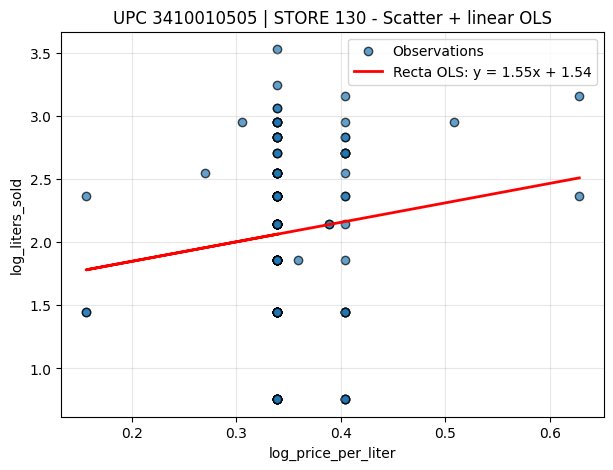

In [11]:
x = df_upc["log_price_per_liter"].values
y = df_upc["log_liters_sold"].values
m, b = np.polyfit(x, y, 1)  # slope and intercept

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.7, edgecolor="k", label="Observations")
plt.plot(
    x,
    m * x + b,
    color="red",
    linewidth=2,
    label=f"Recta OLS: y = {m:.2f}x + {b:.2f}",
)
plt.xlabel("log_price_per_liter")
plt.ylabel("log_liters_sold")
plt.title(f"UPC {upc} | STORE {store} - Scatter + linear OLS")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Time Evolution

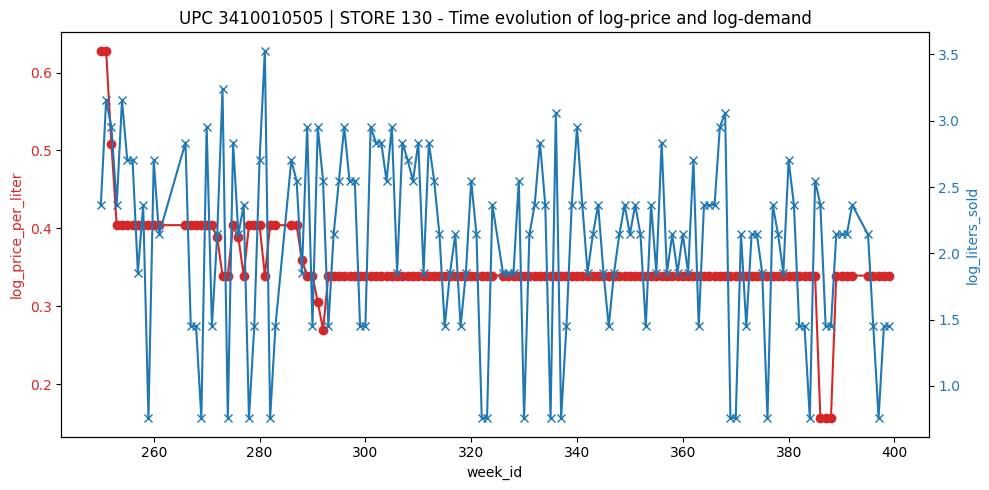

In [12]:
# -------------------------------------------------------------------------
# 6. Time evolution of price and sales (log scale)
# -------------------------------------------------------------------------
df_plot = df_upc.sort_values("week_id").copy()

fig, ax1 = plt.subplots(figsize=(10, 5))

color_price = "tab:red"
color_demand = "tab:blue"

# Price    
ax1.set_xlabel("week_id")
ax1.set_ylabel("log_price_per_liter", color=color_price)
ax1.plot(df_plot["week_id"], df_plot["log_price_per_liter"],
         color=color_price, marker="o", label="log_price_per_liter")
ax1.tick_params(axis="y", labelcolor=color_price)

# Second axis for demand
ax2 = ax1.twinx()
ax2.set_ylabel("log_liters_sold", color=color_demand)
ax2.plot(df_plot["week_id"], df_plot["log_liters_sold"],
         color=color_demand, marker="x", label="log_liters_sold")
ax2.tick_params(axis="y", labelcolor=color_demand)

plt.title(f"UPC {upc} | STORE {store} - Time evolution of log-price and log-demand")
fig.tight_layout()
plt.show()